# Model Analysis



In [6]:
import sys, os
sys.path.insert(0, os.path.abspath('..'))

import json
import sqlite3
import joblib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import precision_score, recall_score, f1_score

from src.features import get_connection

BASE_DIR = os.path.abspath('..')
MODEL_PATH  = os.path.join(BASE_DIR, 'models', 'injury_model.pkl')
SCALER_PATH = os.path.join(BASE_DIR, 'models', 'scaler.pkl')
METADATA_PATH = os.path.join(BASE_DIR, 'models', 'model_metadata.json')

FEATURE_COLS = [
    'workload_score', 'per_change', 'age', 'games_missed_last_season',
    'points_per_game', 'minutes_per_game'
]

## Step 1: Load Model and Data

In [7]:
model = joblib.load(MODEL_PATH)
scaler = joblib.load(SCALER_PATH)

with open(METADATA_PATH) as f:
    metadata = json.load(f)
print('Model loaded:', metadata['model_type'])
print('Trained at:', metadata['trained_at'])
print('F1 score:', metadata['f1_score'])

conn = get_connection()
df = pd.read_sql_query("""
    SELECT psf.player_id, psf.season, psf.workload_score, psf.per_change,
           psf.injury_flag, psf.age, psf.games_missed_last_season,
           ps.points_per_game, ps.minutes_per_game, ps.games_played, ps.position,
           p.first_name || ' ' || p.last_name AS player_name
    FROM player_season_features psf
    JOIN player_stats ps ON psf.player_id = ps.player_id AND psf.season = ps.season
    JOIN players p ON psf.player_id = p.player_id
""", conn)
conn.close()

df = df.dropna(subset=FEATURE_COLS)
print(f'Rows loaded: {len(df)}')

X_scaled = scaler.transform(df[FEATURE_COLS])
df['predicted_flag'] = model.predict(X_scaled)
df['injury_prob'] = model.predict_proba(X_scaled)[:, 1]

Model loaded: Random Forest
Trained at: 2026-05-02T21:29:48.257508
F1 score: 0.9382
Rows loaded: 9282


## Step 2: Accuracy by Position

position  count  precision   recall       f1
     UNK   9282   0.565669 0.863281 0.683483


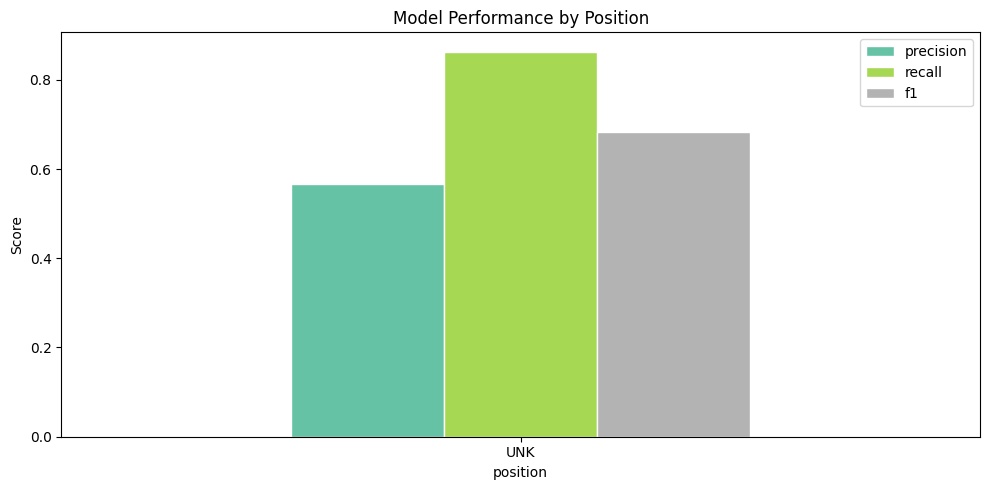

In [8]:
position_results = []
for pos, group in df.groupby('position'):
    if len(group) < 5:
        continue
    position_results.append({
        'position': pos,
        'count': len(group),
        'precision': precision_score(group['injury_flag'], group['predicted_flag'], zero_division=0),
        'recall': recall_score(group['injury_flag'], group['predicted_flag'], zero_division=0),
        'f1': f1_score(group['injury_flag'], group['predicted_flag'], zero_division=0)
    })

if position_results:
    pos_df = pd.DataFrame(position_results)
    print(pos_df.to_string(index=False))
    pos_df.set_index('position')[['precision', 'recall', 'f1']].plot(
        kind='bar', figsize=(10, 5), colormap='Set2', edgecolor='white'
    )
    plt.title('Model Performance by Position')
    plt.ylabel('Score')
    plt.xticks(rotation=0)
    plt.tight_layout()
    plt.show()
else:
    print('Position data is sparse (mostly UNK) -- skipping position breakdown.')

## Step 3: False Negatives



In [9]:
false_negatives = df[(df['injury_flag'] == 1) & (df['predicted_flag'] == 0)].copy()
false_negatives = false_negatives.sort_values('injury_prob')

print(f'Total false negatives: {len(false_negatives)}')
print(f'({len(false_negatives) / df[df["injury_flag"]==1].shape[0] * 100:.1f}% of actual injuries missed)')
print()
print(false_negatives[['player_name', 'season', 'workload_score', 'age', 'injury_prob']].to_string(index=False))

Total false negatives: 560
(13.7% of actual injuries missed)

             player_name  season  workload_score  age  injury_prob
        Donovan Mitchell 2018-19        0.858181   22         0.00
            Kevin Durant 2008-09        0.882508   20         0.00
          Gilbert Arenas 2006-07        0.844479   25         0.00
          Andrew Wiggins 2018-19        0.839830   24         0.00
             Jeff Teague 2013-14        0.800517   26         0.00
           Kevin Garnett 2006-07        0.859802   31         0.00
              Tim Duncan 2002-03        0.913427   27         0.00
             George Hill 2012-13        0.825386   27         0.01
             Ricky Rubio 2017-18        0.745125   27         0.01
      Karl-Anthony Towns 2018-19        0.840473   23         0.01
Kentavious Caldwell-Pope 2016-17        0.816515   24         0.01
   Giannis Antetokounmpo 2017-18        0.910964   23         0.01
          Andre Drummond 2017-18        0.867550   24         0.01


## Step 4: Threshold Tuning



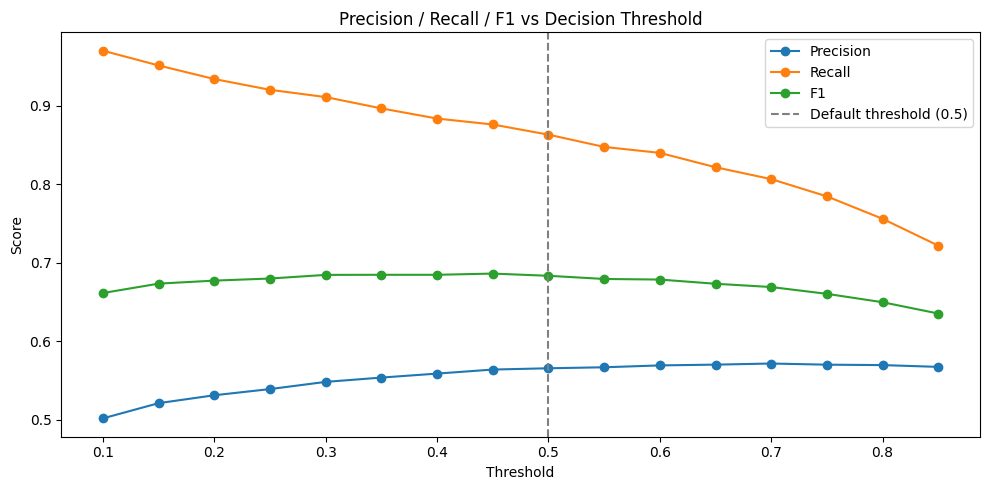


Threshold that maximizes recall: 0.1
  Recall:    0.97
  Precision: 0.50
  F1:        0.66


In [10]:
thresholds = np.arange(0.1, 0.9, 0.05)
results = []

for t in thresholds:
    preds = (df['injury_prob'] >= t).astype(int)
    results.append({
        'threshold': round(t, 2),
        'precision': precision_score(df['injury_flag'], preds, zero_division=0),
        'recall': recall_score(df['injury_flag'], preds, zero_division=0),
        'f1': f1_score(df['injury_flag'], preds, zero_division=0)
    })

thresh_df = pd.DataFrame(results)

fig, ax = plt.subplots(figsize=(10, 5))
ax.plot(thresh_df['threshold'], thresh_df['precision'], label='Precision', marker='o')
ax.plot(thresh_df['threshold'], thresh_df['recall'], label='Recall', marker='o')
ax.plot(thresh_df['threshold'], thresh_df['f1'], label='F1', marker='o')
ax.axvline(0.5, color='gray', linestyle='--', label='Default threshold (0.5)')
ax.set_title('Precision / Recall / F1 vs Decision Threshold')
ax.set_xlabel('Threshold')
ax.set_ylabel('Score')
ax.legend()
plt.tight_layout()
plt.show()

best_recall_row = thresh_df.loc[thresh_df['recall'].idxmax()]
print(f'\nThreshold that maximizes recall: {best_recall_row["threshold"]}')
print(f'  Recall:    {best_recall_row["recall"]:.2f}')
print(f'  Precision: {best_recall_row["precision"]:.2f}')
print(f'  F1:        {best_recall_row["f1"]:.2f}')